<a href="https://colab.research.google.com/github/Mattalukkal/Ai_ML/blob/main/Assignment_On_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predict whether a loan will be approved (Loan_Status),based on applicant details.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath = '/content/drive/MyDrive/Colab Notebooks/DATA/Loan.csv'
df = pd.read_csv(filepath)
df.head() # first 5 columns

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


1. Data Cleaning

* Identify and handle missing values

* Encode categorical variables appropriately

In [5]:

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])


In [6]:
# Drop unnecessary column
df = df.drop('Loan_ID', axis=1)

In [7]:

# Map target variable
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

In [8]:

# Encode categorical variables
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

2. EDA (Exploratory Data Analysis)

* Visualize distributions of LoanAmount, Credit_History, etc.

* Check correlation or feature importance

* Look at approval rate vs. various features (e.g., income, credit history)

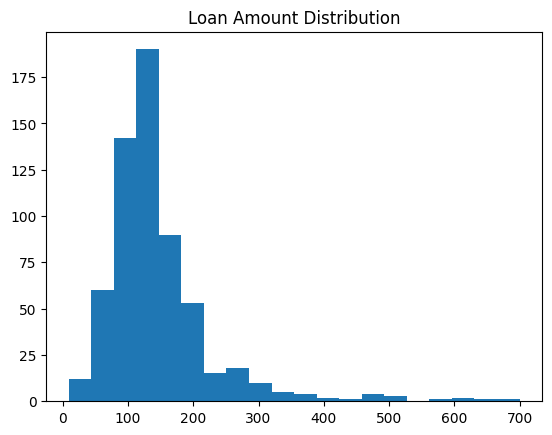

In [10]:
# Distribution of LoanAmount
plt.hist(df['LoanAmount'], bins=20)
plt.title('Loan Amount Distribution')
plt.show()

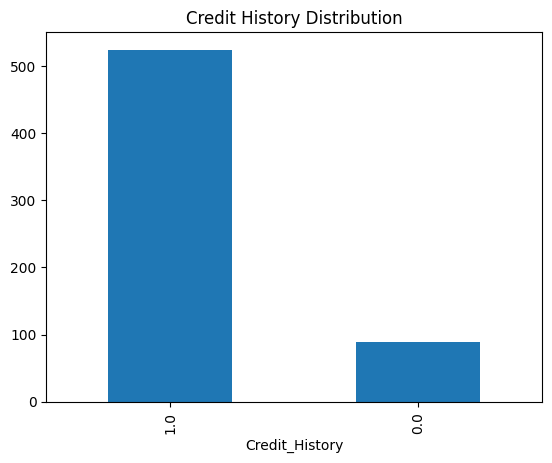

In [11]:
# Bar plot for Credit_History
df['Credit_History'].value_counts().plot(kind='bar')
plt.title('Credit History Distribution')
plt.show()

In [13]:

#Correlation and Feature Importance
print(df.corr()['Loan_Status'].sort_values(ascending=False))

Loan_Status                1.000000
Credit_History             0.540556
Property_Area_Semiurban    0.136540
Married_Yes                0.091478
Dependents_2               0.062384
Gender_Male                0.017987
Self_Employed_Yes         -0.003700
ApplicantIncome           -0.004710
Loan_Amount_Term          -0.022549
Dependents_3+             -0.026123
LoanAmount                -0.033214
Dependents_1              -0.038740
Property_Area_Urban       -0.043621
CoapplicantIncome         -0.059187
Education_Not Graduate    -0.085884
Name: Loan_Status, dtype: float64


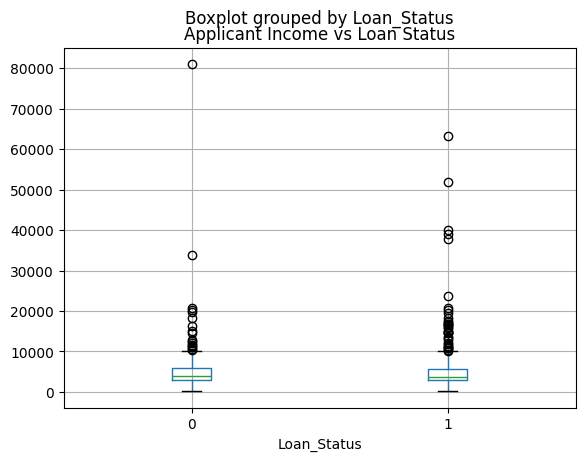

In [14]:
# Approval rate vs. features (e.g., boxplot for income vs status)
df.boxplot(column='ApplicantIncome', by='Loan_Status')
plt.title('Applicant Income vs Loan Status')
plt.show()

In [15]:
print(df.groupby('Credit_History')['Loan_Status'].mean())
print(df.groupby('Property_Area_Semiurban')['Loan_Status'].mean())
print(df.groupby('Married_Yes')['Loan_Status'].mean())

Credit_History
0.0    0.078652
1.0    0.790476
Name: Loan_Status, dtype: float64
Property_Area_Semiurban
False    0.637795
True     0.768240
Name: Loan_Status, dtype: float64
Married_Yes
False    0.629108
True     0.718204
Name: Loan_Status, dtype: float64


3. Modeling

* Build and compare at least 4 classification models, such as:
  * Logistic Regression
  * KNN
  * SVM
  * Decision Tree
  * Random Forest

In [19]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Shape of X (features):", X.shape)
print("\nColumns in X:")
print(X.columns.tolist())
print("\nFirst 3 rows of X (preview):")
print(X.head(3))


Shape of X (features): (614, 14)

Columns in X:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']

First 3 rows of X (preview):
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0             1.0         True        False         False         False   
1             1.0         True         True          True         False   
2             1.0         True         True         False         False   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0   

## Train Logistic Regression Model



In [20]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

metrics_log_reg = {
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg),
    'Recall': recall_score(y_test, y_pred_log_reg),
    'F1 Score': f1_score(y_test, y_pred_log_reg)
}

print("Logistic Regression Model Performance:")
for metric, value in metrics_log_reg.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.7886
Precision: 0.7596
Recall: 0.9875
F1 Score: 0.8587


## Train K-Nearest Neighbors (KNN) Model



In [22]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

metrics_knn = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1 Score': f1_score(y_test, y_pred_knn)
}

print("K-Nearest Neighbors Model Performance:")
for metric, value in metrics_knn.items():
    print(f"{metric}: {value:.4f}")

K-Nearest Neighbors Model Performance:
Accuracy: 0.7642
Precision: 0.7476
Recall: 0.9625
F1 Score: 0.8415


## Train Support Vector Machine (SVM) Model




In [24]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

metrics_svm = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm)
}

print("Support Vector Machine Model Performance:")
for metric, value in metrics_svm.items():
    print(f"{metric}: {value:.4f}")

Support Vector Machine Model Performance:
Accuracy: 0.7967
Precision: 0.7619
Recall: 1.0000
F1 Score: 0.8649


## Train Decision Tree Model

In [26]:
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train_scaled, y_train)
y_pred_dtree = dtree_model.predict(X_test_scaled)

metrics_dtree = {
    'Accuracy': accuracy_score(y_test, y_pred_dtree),
    'Precision': precision_score(y_test, y_pred_dtree),
    'Recall': recall_score(y_test, y_pred_dtree),
    'F1 Score': f1_score(y_test, y_pred_dtree)
}

print("Decision Tree Model Performance:")
for metric, value in metrics_dtree.items():
    print(f"{metric}: {value:.4f}")

Decision Tree Model Performance:
Accuracy: 0.6748
Precision: 0.7326
Recall: 0.7875
F1 Score: 0.7590


## Train Random Forest Model

In [27]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf)
}

print("Random Forest Model Performance:")
for metric, value in metrics_rf.items():
    print(f"{metric}: {value:.4f}")

Random Forest Model Performance:
Accuracy: 0.7805
Precision: 0.7573
Recall: 0.9750
F1 Score: 0.8525


## Compare Model Performance




In [28]:
model_performance = {
    'Logistic Regression': metrics_log_reg,
    'KNN': metrics_knn,
    'SVM': metrics_svm,
    'Decision Tree': metrics_dtree,
    'Random Forest': metrics_rf
}

performance_df = pd.DataFrame(model_performance).T
print("Model Performance Comparison:")
print(performance_df)

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression  0.788618   0.759615  0.9875  0.858696
KNN                  0.764228   0.747573  0.9625  0.841530
SVM                  0.796748   0.761905  1.0000  0.864865
Decision Tree        0.674797   0.732558  0.7875  0.759036
Random Forest        0.780488   0.757282  0.9750  0.852459


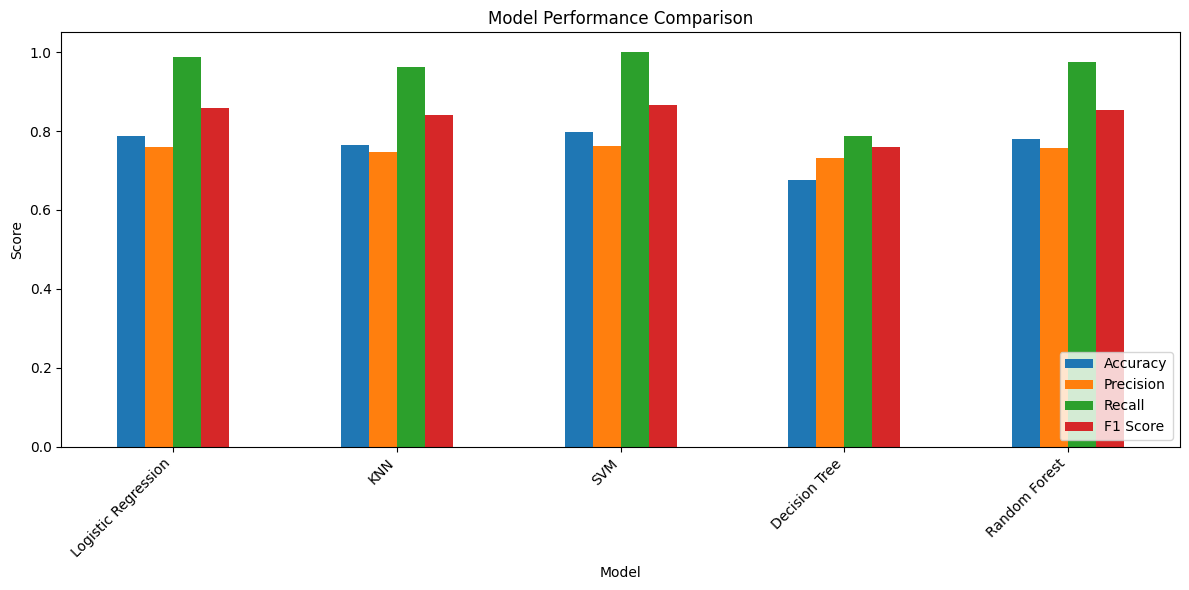

In [29]:
performance_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


*   **Support Vector Machine (SVM)** achieved the highest Accuracy (0.7967) and perfect Recall (1.0000) among all models, with a Precision of 0.7619 and F1 Score of 0.8649.
*   **Logistic Regression** performed strongly with an Accuracy of 0.7886, Precision of 0.7596, Recall of 0.9875, and F1 Score of 0.8587.
*   **Random Forest** showed competitive performance with an Accuracy of 0.7805, Precision of 0.7573, Recall of 0.9750, and F1 Score of 0.8525.
*   **K-Nearest Neighbors (KNN)** had an Accuracy of 0.7642, Precision of 0.7476, Recall of 0.9625, and F1 Score of 0.8415.
*   **Decision Tree** was the lowest-performing model across all metrics, with an Accuracy of 0.6748, Precision of 0.7326, Recall of 0.7875, and F1 Score of 0.7590.
*   All models, except the Decision Tree, exhibited high Recall scores (above 0.96), indicating their effectiveness in identifying positive cases.

### Insights
*   The SVM model appears to be the most robust performer for this dataset, especially given its high accuracy and perfect recall, suggesting it is highly effective at identifying all positive cases.
*   Further hyperparameter tuning for the top-performing models (SVM, Logistic Regression, and Random Forest) could potentially enhance their performance even more.


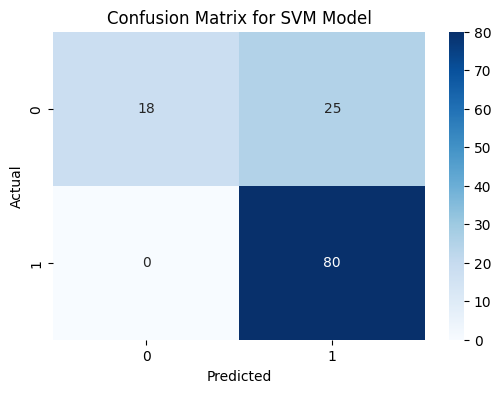

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()